In [1]:
import pandas as pd
# from LabData.DataLoaders.GutMBLoader import GutMBLoader
# from LabData.DataLoaders.SubjectLoader import SubjectLoader
# from LabData.DataLoaders.DietLoggingLoader import DietLoggingLoader
# from LabData.DataAnalyses.TenK_Trajectories.utils import get_diet_logging_around_stage
import seaborn as sns
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pickle
import lightgbm as lgb
import math
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr
import re

In [2]:
home_path = '/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/'
SPECIES = 'segal_species' # 'segal_species' or 'mpa_species'

In [3]:
species = '' if SPECIES == 'segal_species' else '_mpa'

diet_mb = pd.read_pickle(home_path + f"data/{SPECIES}/diet_mb.pkl")
with open(home_path + f'data/{SPECIES}/my_lists.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)
base_features, all_features, targets = loaded_lists

diet_mb

,Acorn squash,Alfalfa sprouts,Almond Beverage,Almond flour,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple Vinegar,...,Irritable Bowel Syndrome (IBS),Peptic Ulcer Disease,Gallstone disease,Asthma,Atopic dermatitis,Psoriasis,Allergy,Depression,Anxiety,Hypothyroidism
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.016416,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10K_1001201093,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.013895,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1002254441,0.0,0.0,0.0,0.0,0.0,0.081238,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1003113258,0.0,0.0,0.0,0.0,0.0,0.002048,0.0,0.008929,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1007330152,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9996884777,0.0,0.0,0.0,0.0,0.0,0.002401,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_9998420917,0.0,0.0,0.0,0.0,0.0,0.019995,0.0,0.018783,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_9998635752,0.0,0.0,0.0,0.0,0.0,0.001607,0.0,0.011305,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
def read_results(df):
    output = []
    for col in df.columns:
        output.append(df[col])
    return tuple(output)

Ridge

In [5]:
ridge_diet_scores, ridge_diet_pvalues, ridge_diet_coefs, ridge_diet_preds, ridge_diet_targets = read_results(pd.read_pickle(home_path +f"data/regression/{SPECIES}/output_ridge_abundance.pkl"))

<Figure size 1800x1800 with 0 Axes>

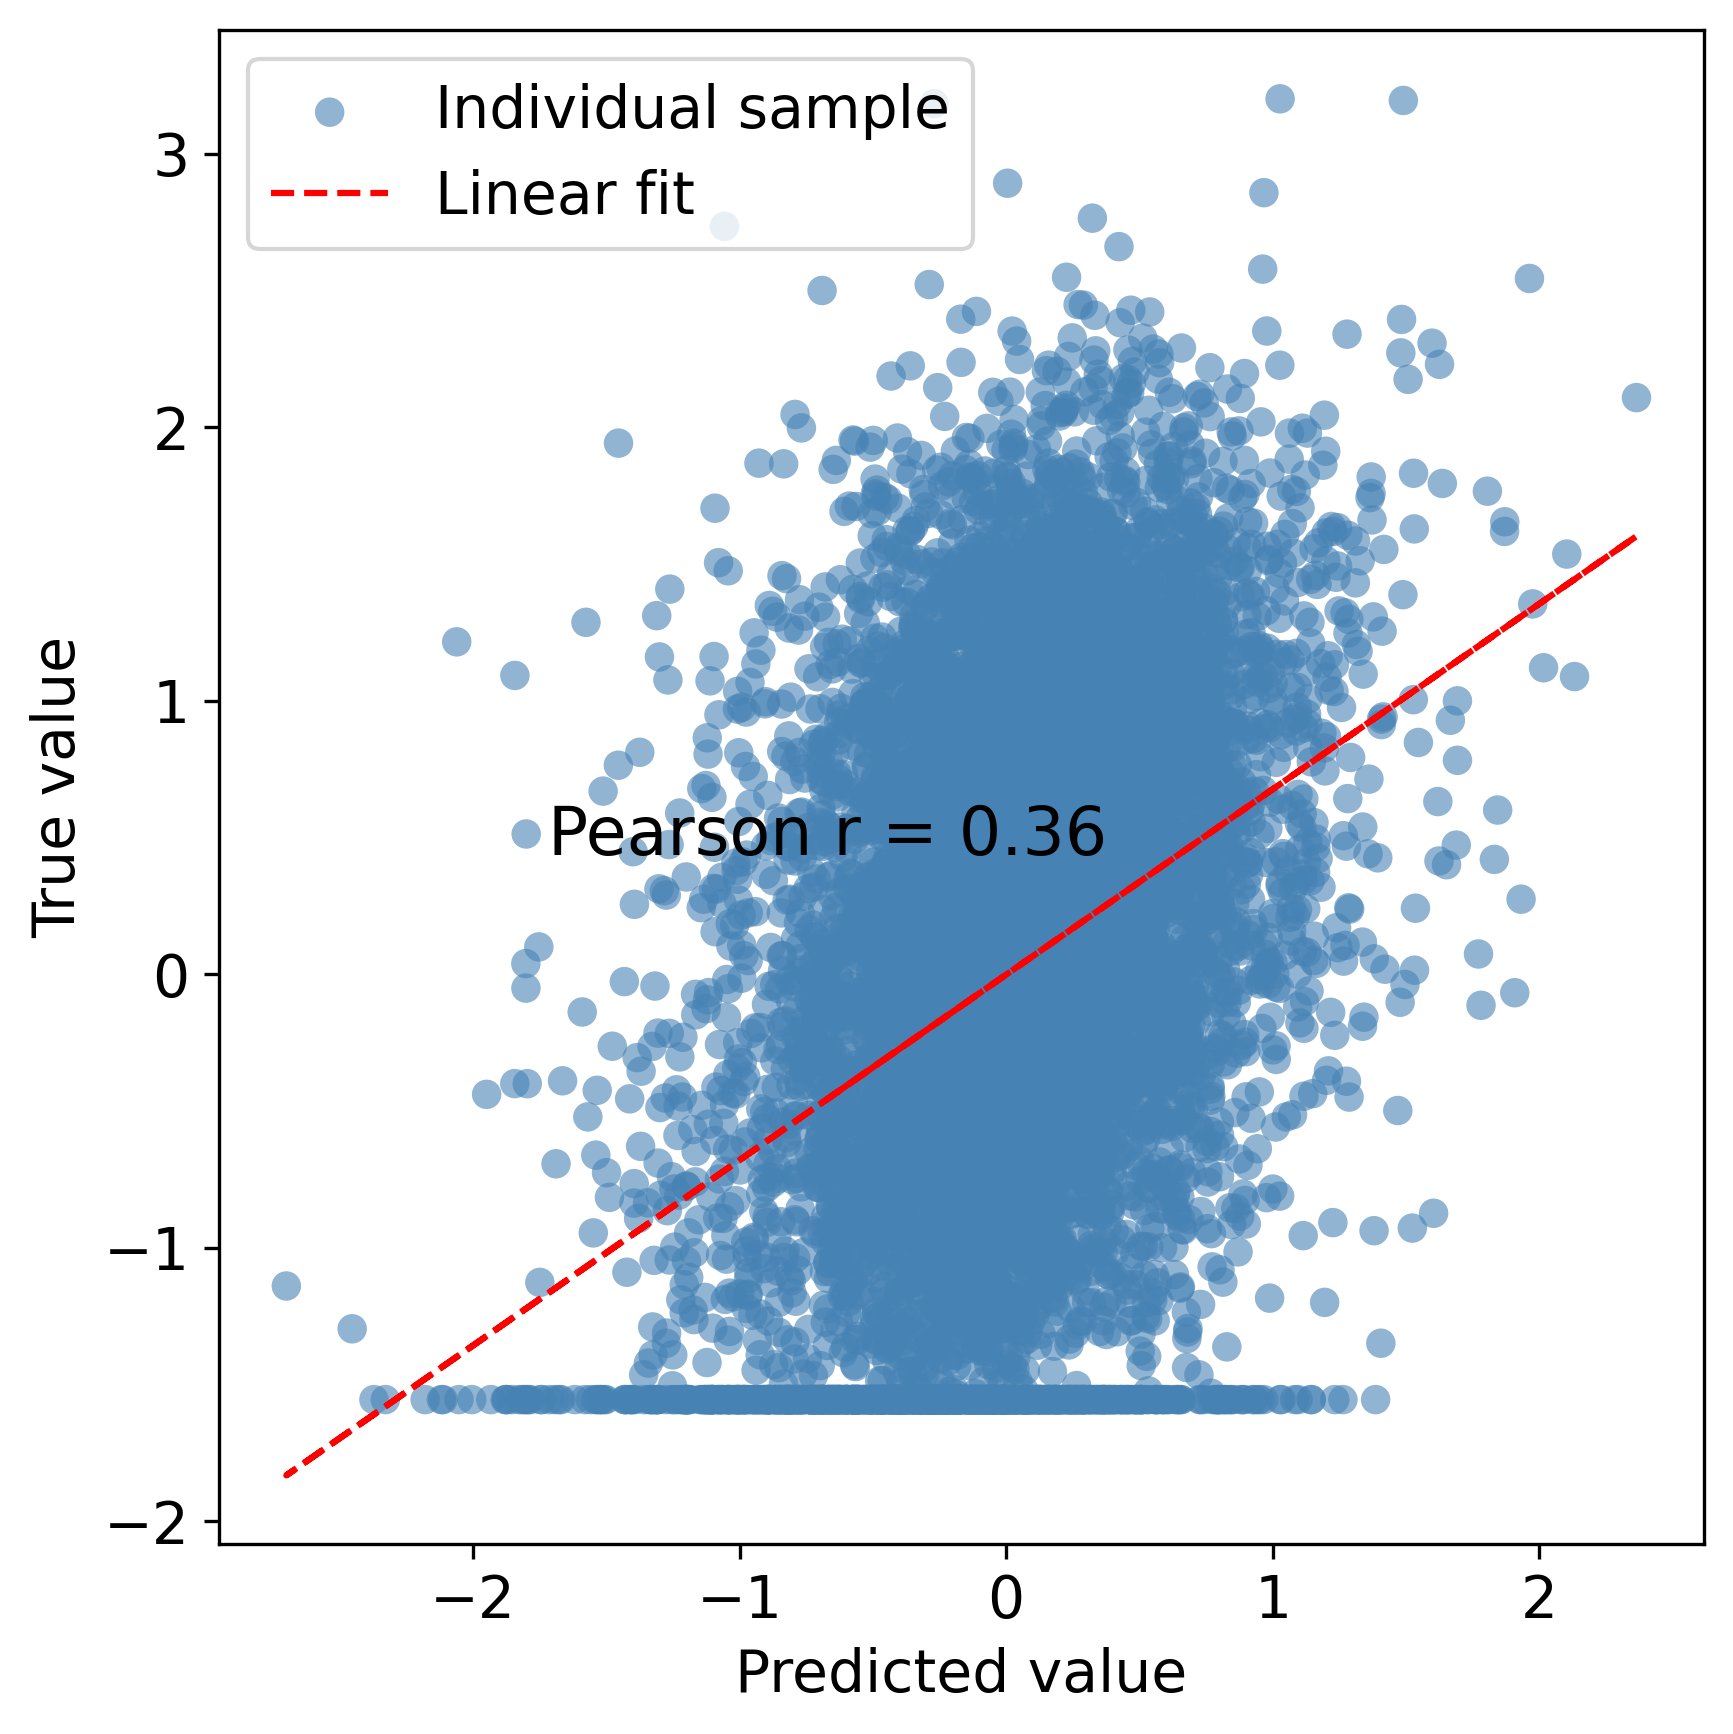

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm

# Pick one bacterial target index
i = 594  # Streptococcus Thermophilus

plt.figure(figsize=(6, 6), dpi=300)

# Extract prediction & target arrays
y_pred = np.array(ridge_diet_preds.iloc[i])
y_true = np.array(ridge_diet_targets.iloc[i])

# Compute Pearson correlation
r_val, p_val = stats.pearsonr(y_pred, y_true)

# Confirm via statsmodels (optional)
x = (y_pred - np.mean(y_pred)) / np.std(y_pred)
y = (y_true - np.mean(y_true)) / np.std(y_true)
model = sm.OLS(y, sm.add_constant(x)).fit()

# Plot style
plt.style.use('default')
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(6, 6), dpi=300)

# Scatter
plt.scatter(
    y_pred, y_true,
    color='steelblue',
    alpha=0.6,
    edgecolor='none',
    s=50,
    label="Individual sample"
)

# Regression line
slope, intercept = np.polyfit(y_pred, y_true, 1)
plt.plot(
    y_pred,
    slope * y_pred + intercept,
    'r--',
    linewidth=1.5,
    label='Linear fit'
)

# --- Place text close to red line dynamically ---
# Pick a representative x position (e.g., midrange)
x_line = np.median(y_pred)
y_line = slope * x_line + intercept

# Offset slightly above the red line
plt.text(
    x_line - 0.12 * (plt.xlim()[1] - plt.xlim()[0]),  # shift left
    y_line + 0.07 * (plt.ylim()[1] - plt.ylim()[0]),  # vertical offset
    f"Pearson r = {r_val:.2f}",
    color='black',
    ha='center',
    va='bottom',
    fontsize=16
)

# Labels and title
plt.xlabel("Predicted value")
plt.ylabel("True value")
# plt.title("Streptococcus Thermophilus")

# Legend and layout
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
plt.clf()


LGBM

In [7]:
lgbm_diet_scores, lgbm_diet_pvalues, lgbm_diet_coefs, lgbm_diet_preds, lgbm_diet_targets = read_results(pd.read_pickle(home_path +f"data/regression/{SPECIES}/output_LGBM_abundance.pkl"))

In [8]:
lgbm_diet_scores.sort_values(ascending=False)
# i=594 strep thermophilus

594    0.427113
46     0.422091
223    0.387587
34     0.361794
507    0.323834
         ...   
496    0.001635
694    0.000195
8     -0.000144
446   -0.009569
249   -0.012802
Name: 0, Length: 724, dtype: float64

<Figure size 1800x1800 with 0 Axes>

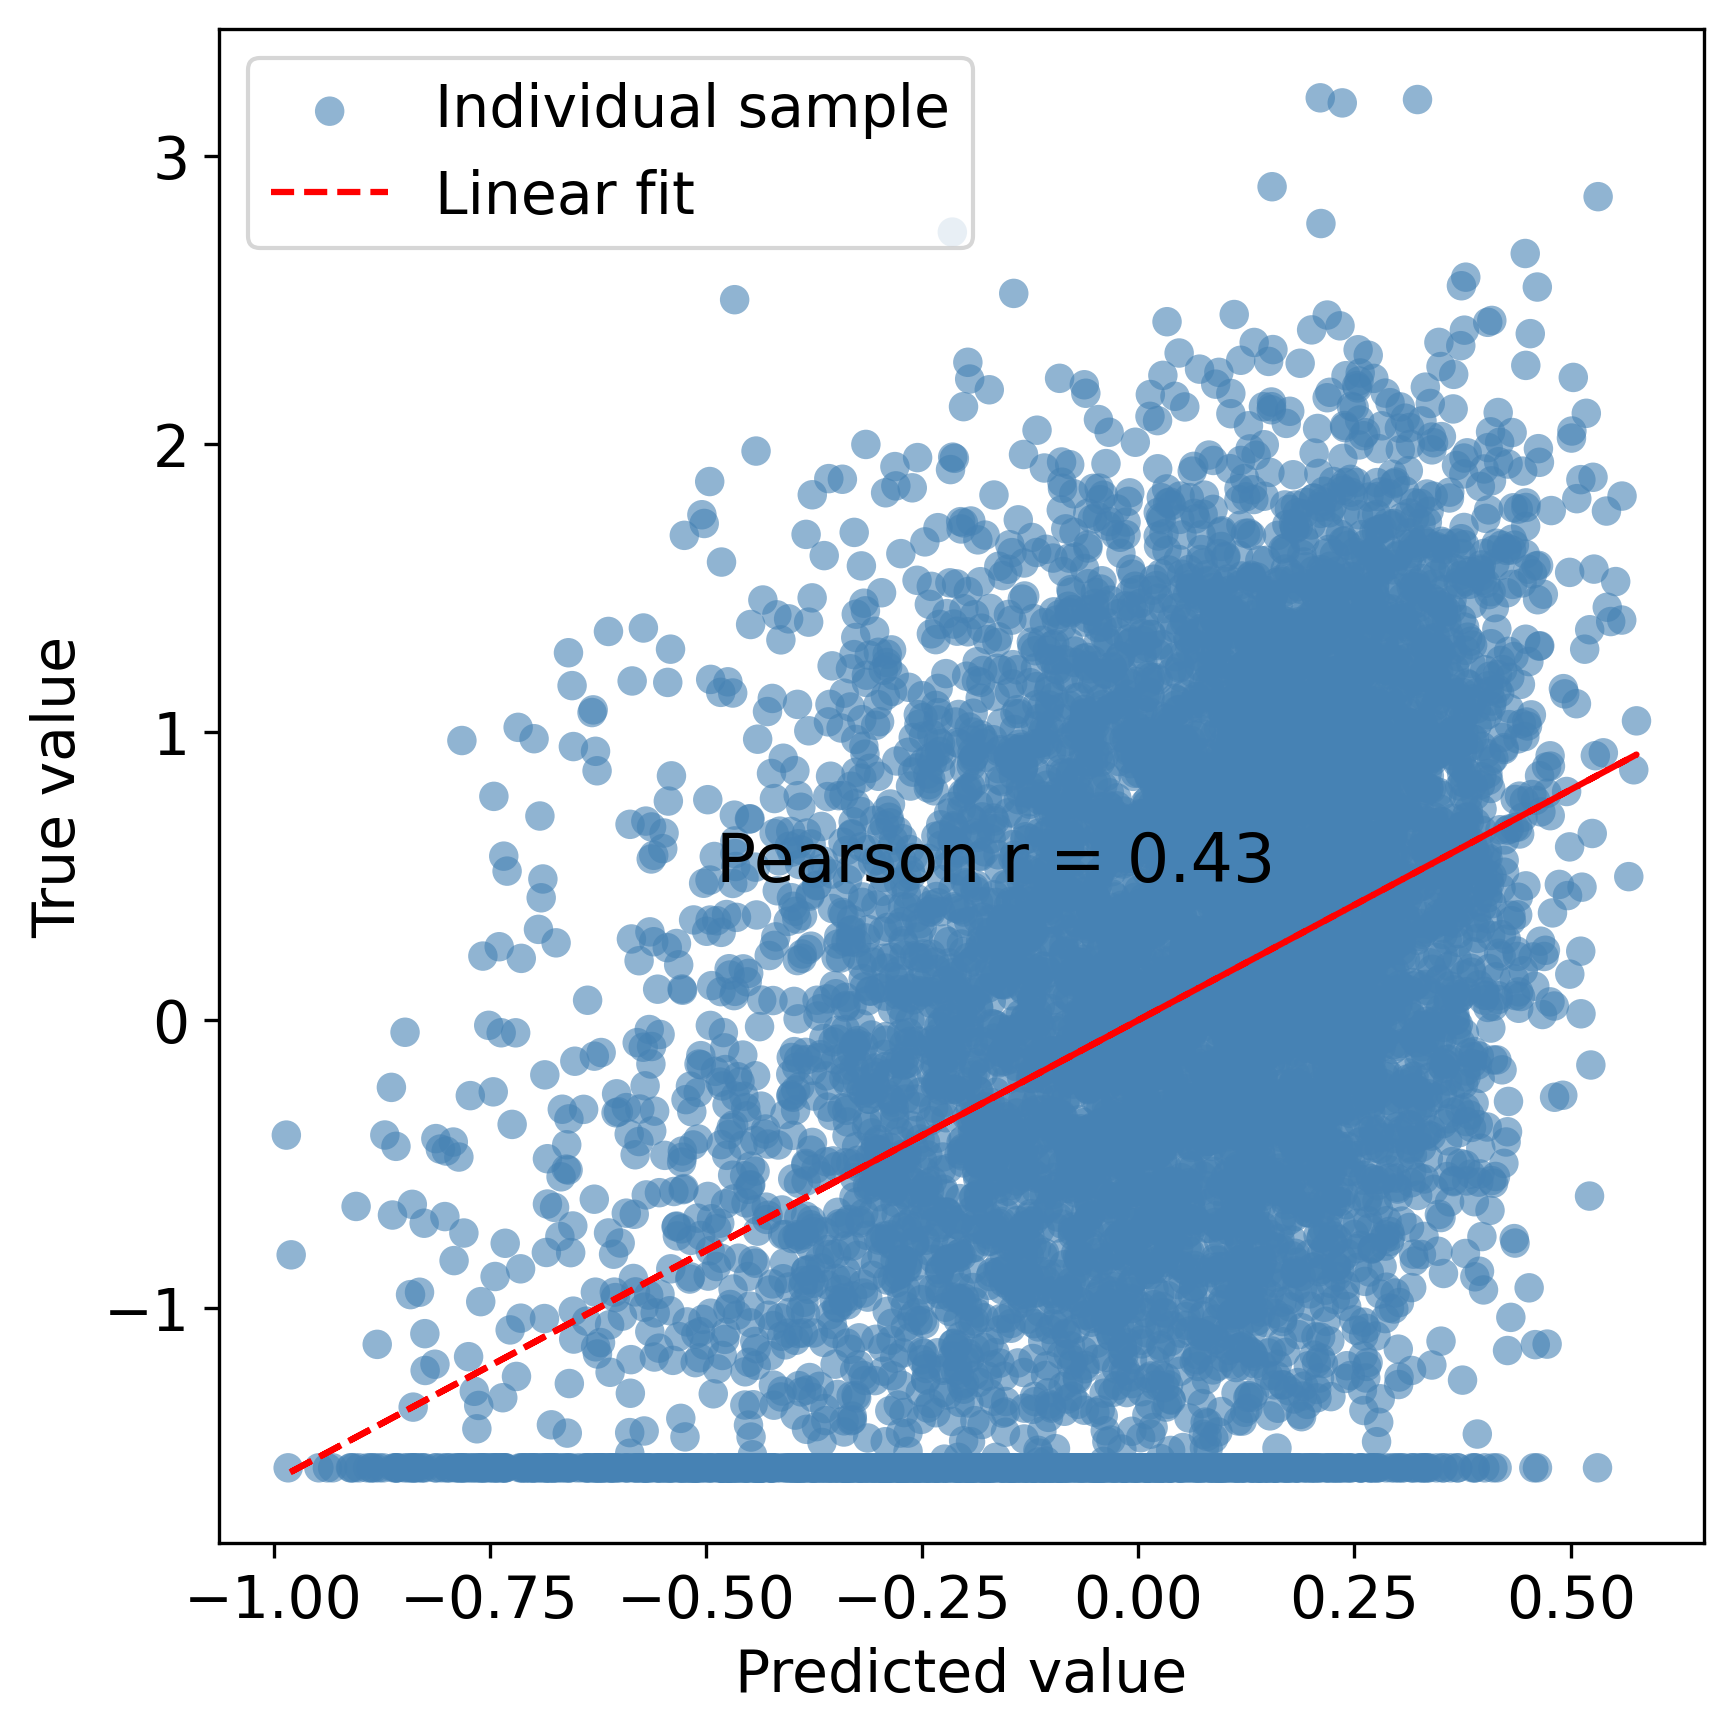

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm

# Pick one bacterial target index
i = 594  # Streptococcus Thermophilus

plt.figure(figsize=(6, 6), dpi=300)

# Extract prediction & target arrays
y_pred = np.array(lgbm_diet_preds.iloc[i])
y_true = np.array(lgbm_diet_targets.iloc[i])

# Compute Pearson correlation
r_val, p_val = stats.pearsonr(y_pred, y_true)

# Confirm via statsmodels (optional)
x = (y_pred - np.mean(y_pred)) / np.std(y_pred)
y = (y_true - np.mean(y_true)) / np.std(y_true)
model = sm.OLS(y, sm.add_constant(x)).fit()

# Plot style
plt.style.use('default')
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(6, 6), dpi=300)

# Scatter
plt.scatter(
    y_pred, y_true,
    color='steelblue',
    alpha=0.6,
    edgecolor='none',
    s=50,
    label="Individual sample"
)

# Regression line
slope, intercept = np.polyfit(y_pred, y_true, 1)
plt.plot(
    y_pred,
    slope * y_pred + intercept,
    'r--',
    linewidth=1.5,
    label='Linear fit'
)

# --- Place text close to red line dynamically ---
# Pick a representative x position (e.g., midrange)
x_line = np.median(y_pred)
y_line = slope * x_line + intercept

# Offset slightly above the red line
plt.text(
    x_line - 0.12 * (plt.xlim()[1] - plt.xlim()[0]),  # shift left
    y_line + 0.07 * (plt.ylim()[1] - plt.ylim()[0]),  # vertical offset
    f"Pearson r = {r_val:.2f}",
    color='black',
    ha='center',
    va='bottom',
    fontsize=16
)

# Labels and title
plt.xlabel("Predicted value")
plt.ylabel("True value")
# plt.title("Streptococcus Thermophilus")

# Legend and layout
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
plt.clf()


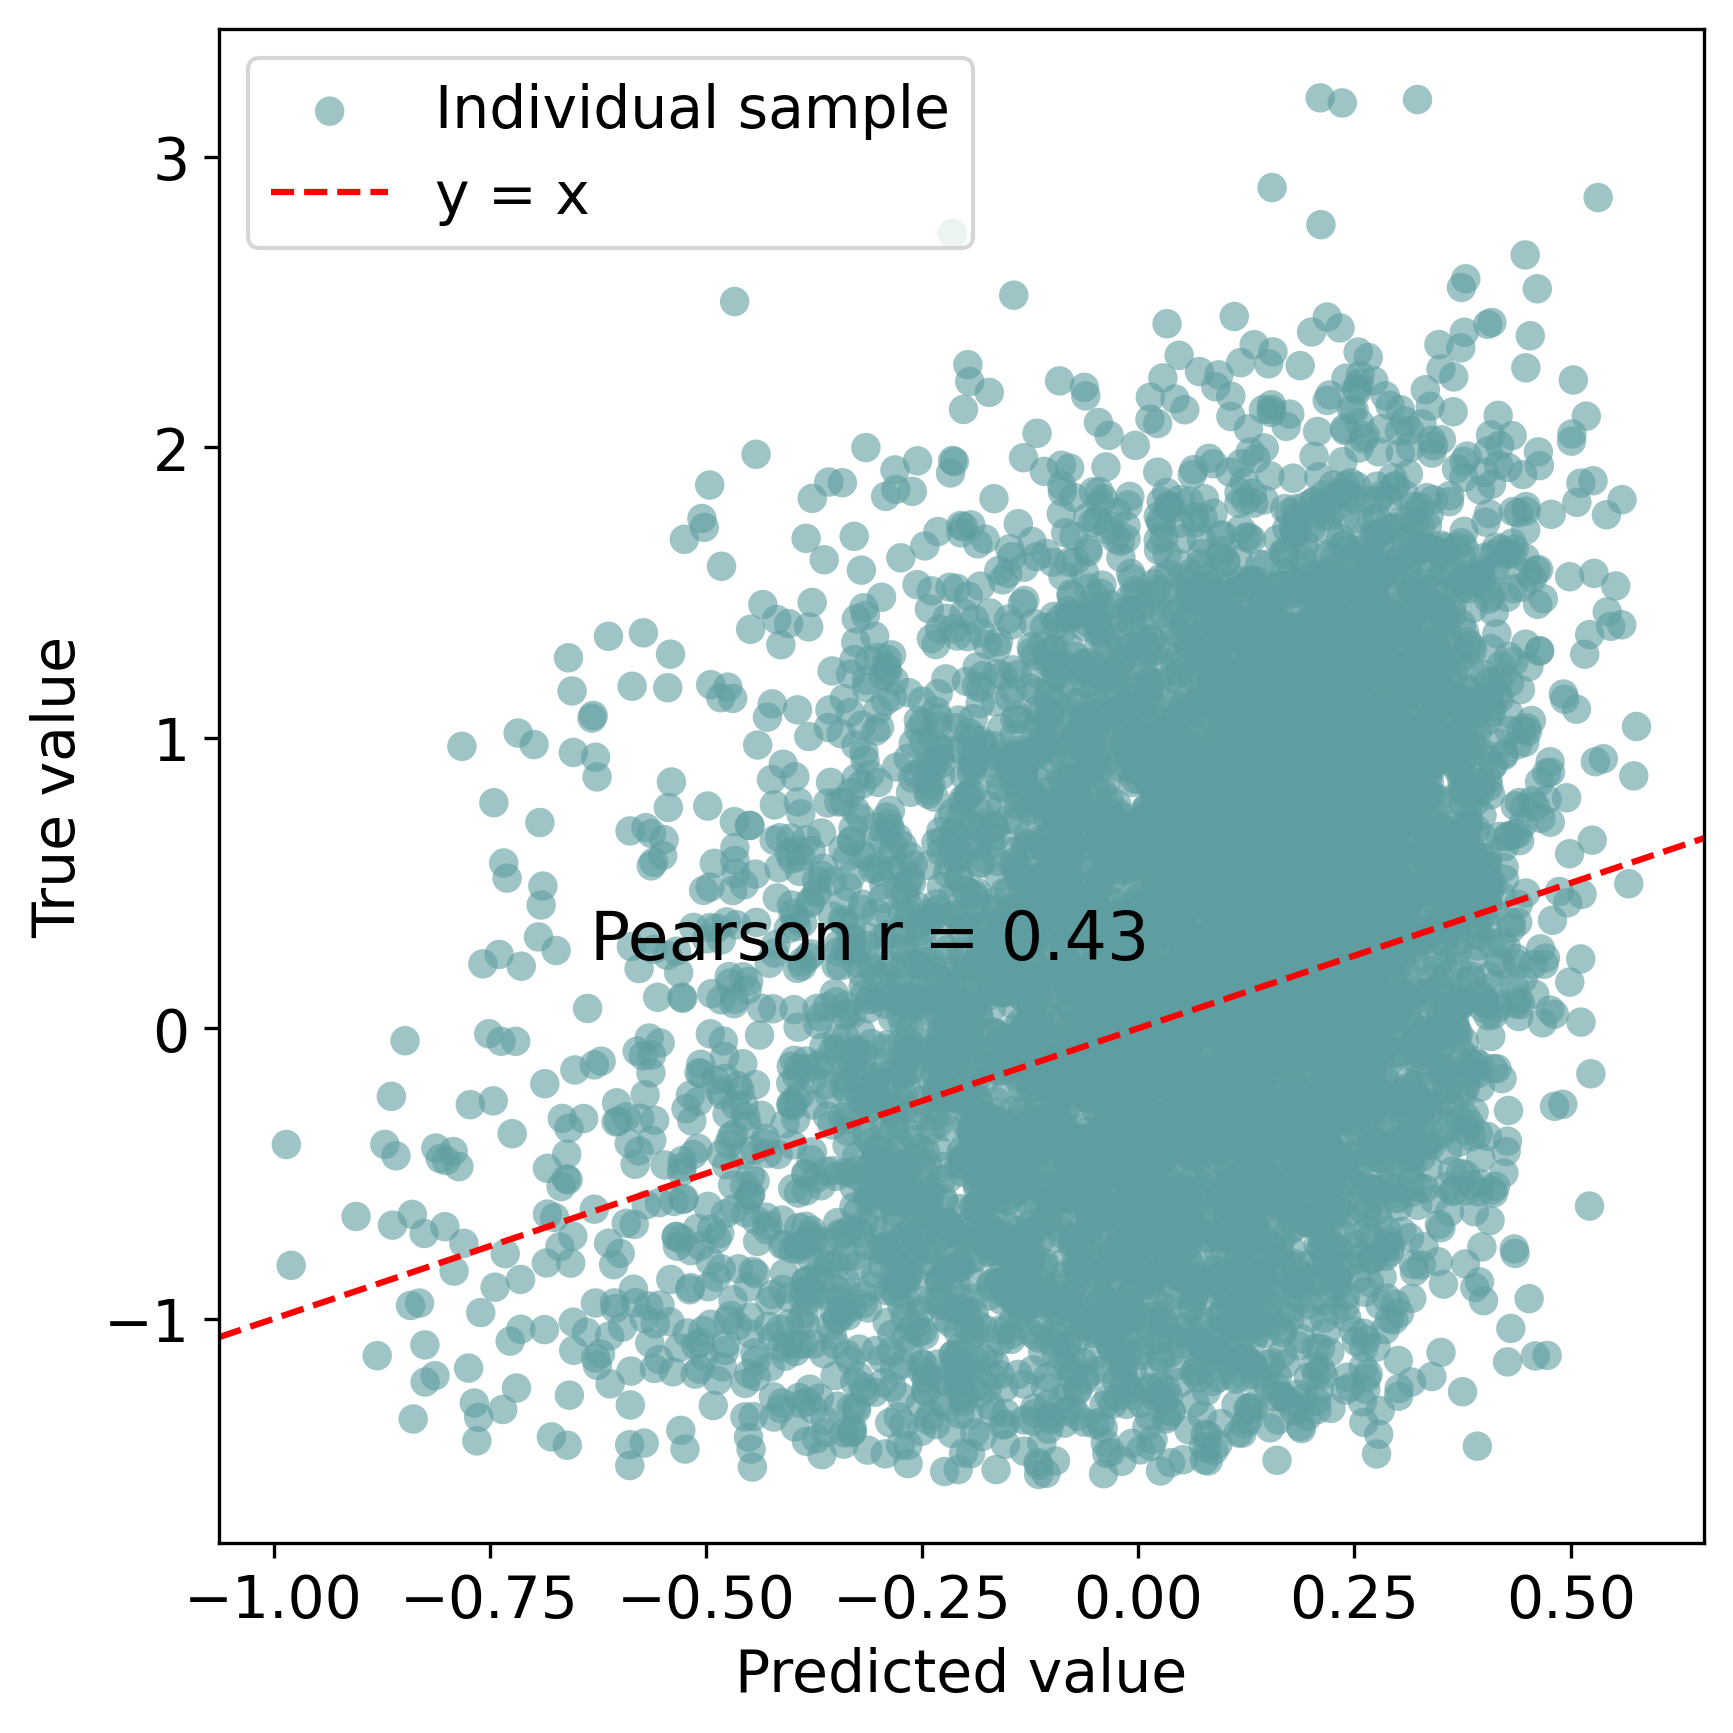

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ======================
# SETTINGS
# ======================
SPECIES = "segal_species"
home_path = "/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/"
MICROBE_I = 594

# Axis behavior:
AXIS_MODE = "minmax"      # "minmax" (no clipping) or "percentile"
PCTL_LIM = (0.05, 99.95)  # used only if AXIS_MODE="percentile"
PAD_FRAC = 0.05

# Floor detection (absent flat-line in y_true)
DECIMALS_FOR_FLOOR = 3
MIN_FLOOR_FRACTION = 0.01

DPI = 300
# ======================



def detect_constant_floor_from_targets(y_true: np.ndarray,
                                       decimals: int = 3,
                                       min_frac: float = 0.01):
    y = np.asarray(y_true, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    y_round = np.round(y, decimals)
    vals, cnts = np.unique(y_round, return_counts=True)
    j = int(np.argmax(cnts))
    floor_val = float(vals[j])
    floor_frac = float(cnts[j]) / float(cnts.sum())

    return floor_val if floor_frac >= min_frac else None


def compute_limits(a: np.ndarray, mode: str = "minmax", pctl=(0.05, 99.95), pad_frac: float = 0.05):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return (-1, 1)

    if mode == "percentile":
        lo, hi = np.percentile(a, list(pctl))
    else:
        lo, hi = float(np.min(a)), float(np.max(a))

    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = float(np.min(a)), float(np.max(a))
        if lo == hi:
            lo -= 1.0
            hi += 1.0

    span = hi - lo
    return (lo - pad_frac * span, hi + pad_frac * span)


# ============================================================
# READ -> FILTER -> PLOT IMMEDIATELY
# (assumes read_results() exists in your environment)
# ============================================================
obj = pd.read_pickle(home_path + f"data/regression/{SPECIES}/output_LGBM_abundance.pkl")
lgbm_diet_scores, lgbm_diet_pvalues, lgbm_diet_coefs, lgbm_diet_preds, lgbm_diet_targets = read_results(obj)

y_pred = np.asarray(lgbm_diet_preds.iloc[MICROBE_I], dtype=float)
y_true = np.asarray(lgbm_diet_targets.iloc[MICROBE_I], dtype=float)

# drop non-finite
ok = np.isfinite(y_pred) & np.isfinite(y_true)
x_all = y_pred[ok]
y_all = y_true[ok]

    # Pearson r (full cohort)
if x_all.size >= 3 and np.std(x_all) > 0 and np.std(y_all) > 0:
    r_all, p_all = stats.pearsonr(x_all, y_all)
else:
    r_all, p_all = np.nan, np.nan

# detect floor from y_true itself and remove absent flat-line points
floor_val = detect_constant_floor_from_targets(y_all, decimals=DECIMALS_FOR_FLOOR, min_frac=MIN_FLOOR_FRACTION)
if floor_val is not None:
    tol = 0.5 * (10 ** (-DECIMALS_FOR_FLOOR))
    present_mask = np.abs(y_all - floor_val) > tol
else:
    present_mask = np.ones_like(y_all, dtype=bool)

x = x_all[present_mask]
y = y_all[present_mask]

# Pearson r (present-only)
r_val, _ = stats.pearsonr(x, y) if x.size >= 3 else (np.nan, np.nan)

# Plot
plt.style.use("default")
plt.rcParams.update({"font.size": 14})
fig = plt.figure(figsize=(6, 6), dpi=DPI)

DOT_COLOR = "#5f9ea0"
plt.scatter(
    x, y,
    alpha=0.6,
    color=DOT_COLOR,
    edgecolor="none",
    s=50,
    label="Individual sample"
)

# limits
xlim = compute_limits(x, mode=AXIS_MODE, pctl=PCTL_LIM, pad_frac=PAD_FRAC)
ylim = compute_limits(y, mode=AXIS_MODE, pctl=PCTL_LIM, pad_frac=PAD_FRAC)
plt.xlim(xlim)
plt.ylim(ylim)

# y = x
line_min = max(xlim[0], ylim[0])
line_max = min(xlim[1], ylim[1])
plt.plot([line_min, line_max], [line_min, line_max], "r--", lw=1.5, label="y = x")

# Pearson r text ONLY
plt.text(
    0.25, 0.42,
    f"Pearson r = {r_all:.2f}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=16
)

plt.xlabel("Predicted value")
plt.ylabel("True value")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
plt.close(fig)


### For bifidobacterium longum

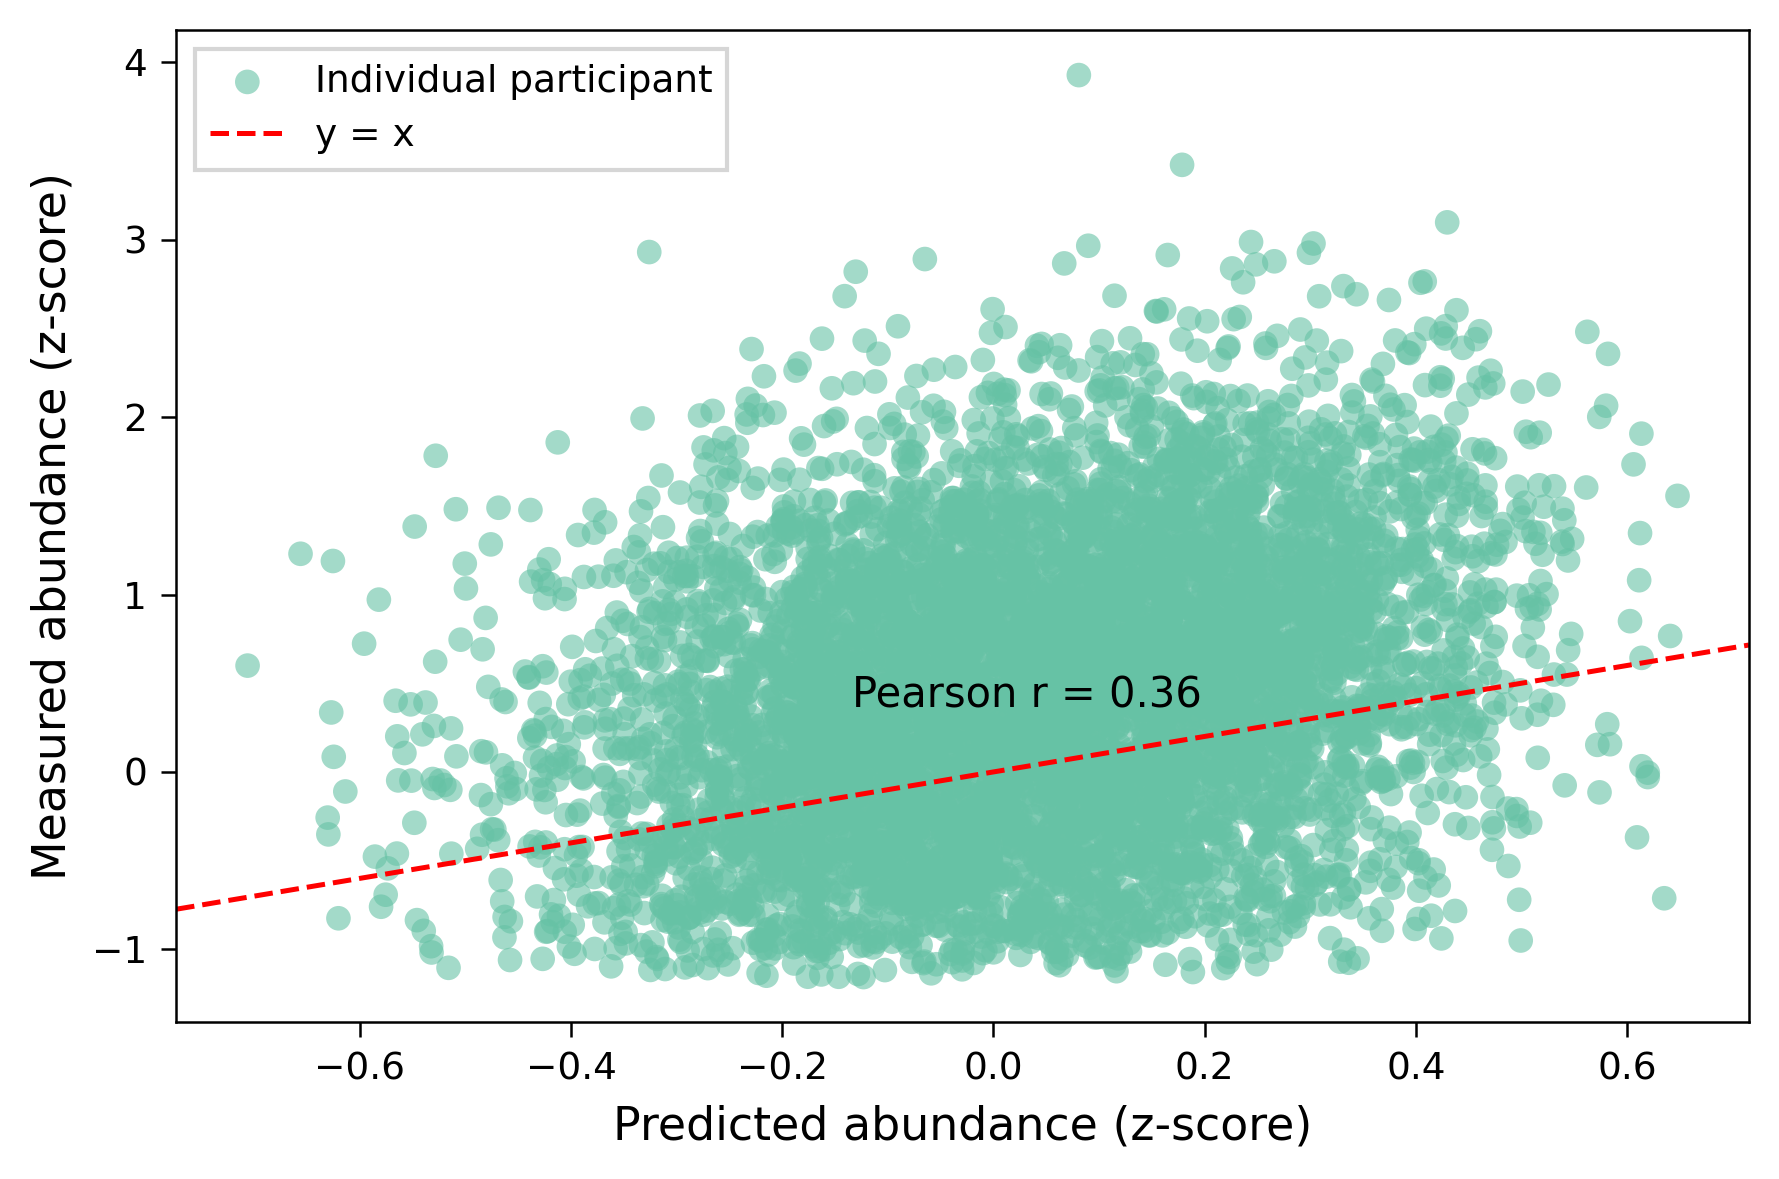

In [18]:
# ====================================================================
# Predicted vs True scatter — Nature panel-safe version
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats

# ======================
# SETTINGS
# ======================
SPECIES = "segal_species"
home_path = "/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/"
MICROBE_I = 34

AXIS_MODE = "minmax"      # "minmax" or "percentile"
PCTL_LIM = (0.05, 99.95)
PAD_FRAC = 0.05

DECIMALS_FOR_FLOOR = 3
MIN_FLOOR_FRACTION = 0.01

DPI = 300
# ======================


# --------------------------------------------------------------------
# 0. Reset + Nature style (IDENTICAL to other panels)
# --------------------------------------------------------------------
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("nature_single.mplstyle")

FONT = 9
mpl.rcParams.update({
    "font.size": FONT,
    "axes.labelsize": FONT + 2,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT,
})


# --------------------------------------------------------------------
# 1. Colors — SAME Set2 source
# --------------------------------------------------------------------
set2 = cm.get_cmap("Set2").colors
DOT_COLOR = set2[0]


# --------------------------------------------------------------------
# 2. Helper functions (unchanged)
# --------------------------------------------------------------------
def detect_constant_floor_from_targets(y_true, decimals=3, min_frac=0.01):
    y = np.asarray(y_true, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    y_round = np.round(y, decimals)
    vals, cnts = np.unique(y_round, return_counts=True)
    j = int(np.argmax(cnts))
    floor_val = float(vals[j])
    floor_frac = float(cnts[j]) / float(cnts.sum())

    return floor_val if floor_frac >= min_frac else None


def compute_limits(a, mode="minmax", pctl=(0.05, 99.95), pad_frac=0.05):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return (-1, 1)

    if mode == "percentile":
        lo, hi = np.percentile(a, list(pctl))
    else:
        lo, hi = float(np.min(a)), float(np.max(a))

    if lo == hi:
        lo -= 1.0
        hi += 1.0

    span = hi - lo
    return (lo - pad_frac * span, hi + pad_frac * span)


# --------------------------------------------------------------------
# 3. Load results
# --------------------------------------------------------------------
obj = pd.read_pickle(home_path + f"data/regression/{SPECIES}/output_LGBM_abundance.pkl")
lgbm_diet_scores, lgbm_diet_pvalues, lgbm_diet_coefs, lgbm_diet_preds, lgbm_diet_targets = read_results(obj)

y_pred = np.asarray(lgbm_diet_preds.iloc[MICROBE_I], dtype=float)
y_true = np.asarray(lgbm_diet_targets.iloc[MICROBE_I], dtype=float)

ok = np.isfinite(y_pred) & np.isfinite(y_true)
x_all = y_pred[ok]
y_all = y_true[ok]

# Pearson r (full)
r_all, _ = stats.pearsonr(x_all, y_all) if x_all.size >= 3 else (np.nan, np.nan)

# Remove absent floor
floor_val = detect_constant_floor_from_targets(y_all, DECIMALS_FOR_FLOOR, MIN_FLOOR_FRACTION)
if floor_val is not None:
    tol = 0.5 * (10 ** (-DECIMALS_FOR_FLOOR))
    present_mask = np.abs(y_all - floor_val) > tol
else:
    present_mask = np.ones_like(y_all, dtype=bool)

x = x_all[present_mask]
y = y_all[present_mask]


# --------------------------------------------------------------------
# 4. Figure — CANONICAL panel size
# --------------------------------------------------------------------
FIG_W = 6.0
FIG_H = 4.0     # square-ish but still panel-safe

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)

ax.scatter(
    x, y,
    s=35,
    alpha=0.6,
    color=DOT_COLOR,
    edgecolor="none",
    label="Individual participant",
)

# Axis limits
xlim = compute_limits(x, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ylim = compute_limits(y, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# y = x reference
line_min = max(xlim[0], ylim[0])
line_max = min(xlim[1], ylim[1])
ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="red",
    linewidth=1.2,
    label="y = x",
)

# Pearson r annotation (same scale as other panels)
ax.text(
    0.43, 0.35,                      # EXACT same relative position
    f"Pearson r = {r_all:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=FONT + 1,
)

ax.set_xlabel("Predicted abundance (z-score)")
ax.set_ylabel("Measured abundance (z-score)")

ax.legend(frameon=True, fancybox=False, loc='upper left')
fig.tight_layout()

plt.show()
plt.close(fig)


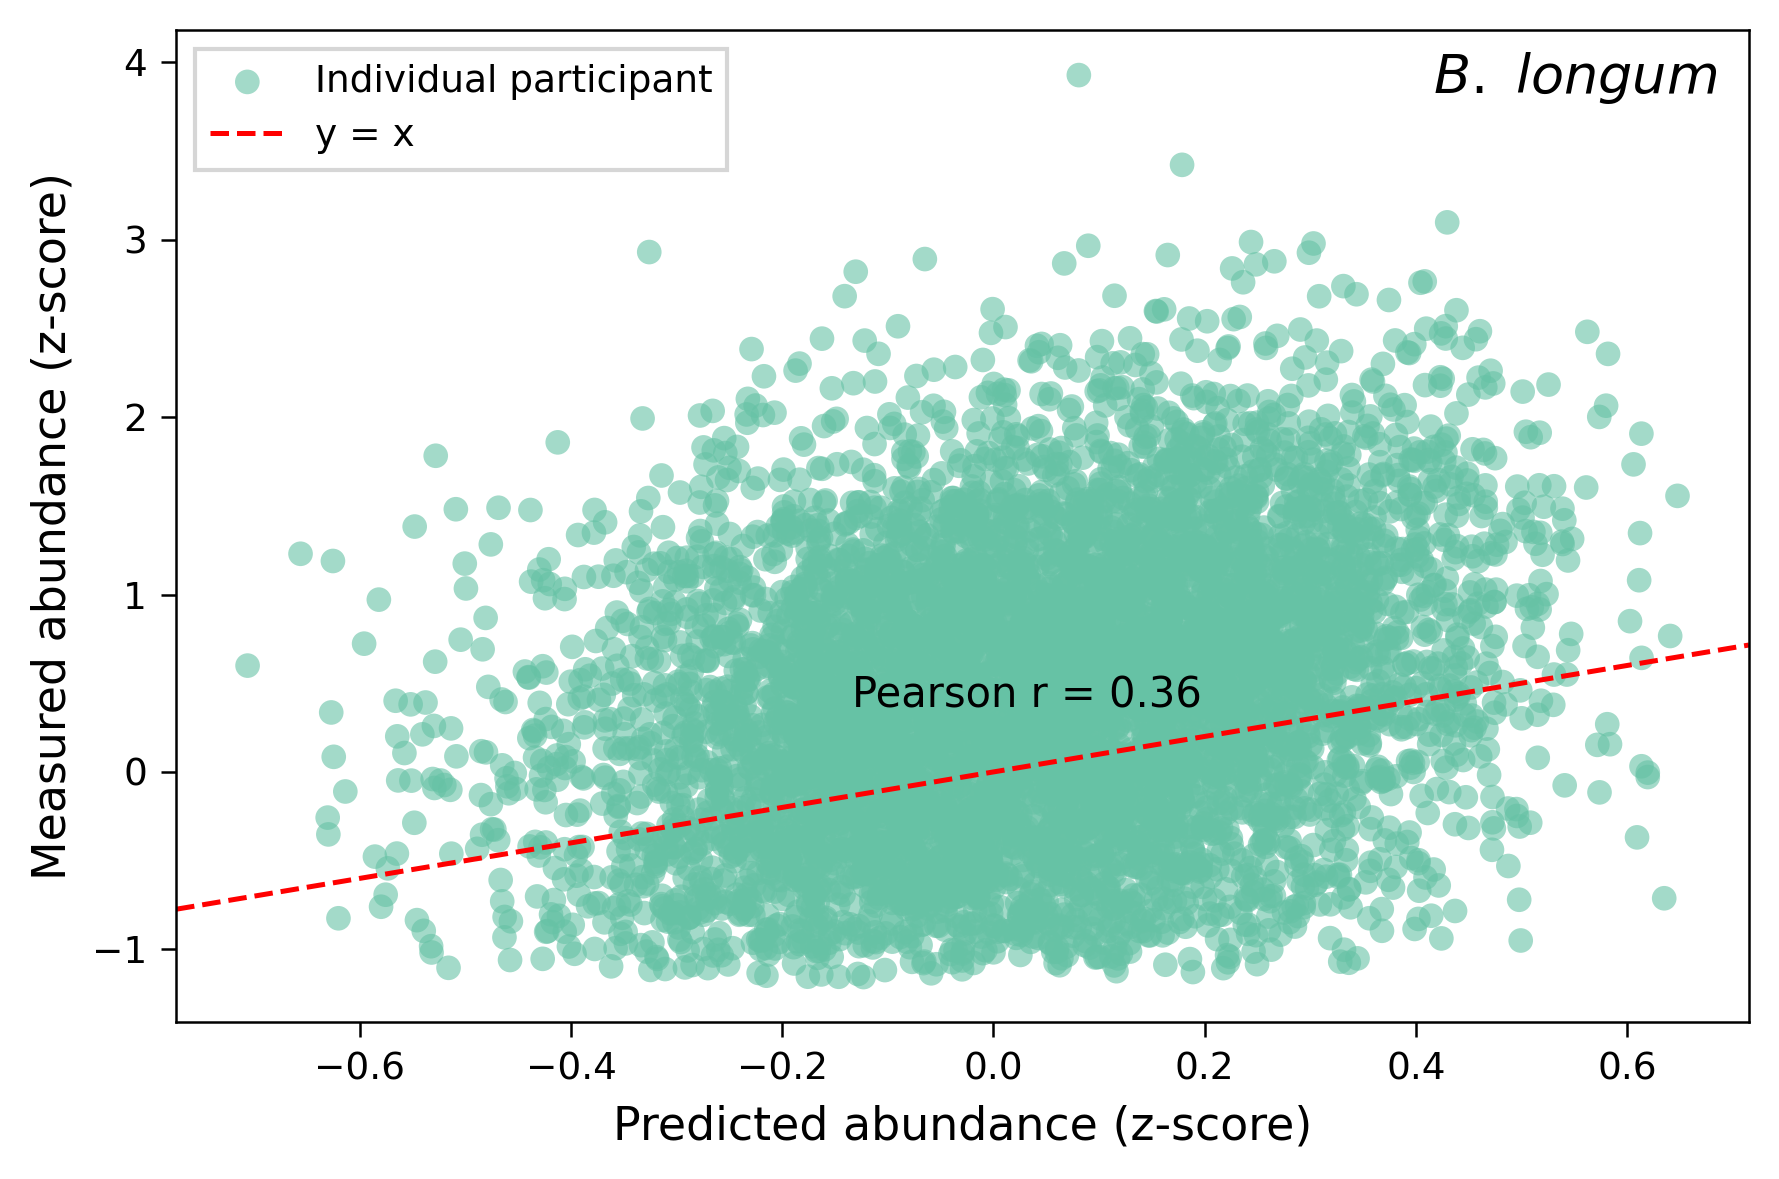

In [29]:
# ====================================================================
# Predicted vs True scatter — Nature panel-safe version
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats

# ======================
# SETTINGS
# ======================
SPECIES = "segal_species"
home_path = "/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/"
MICROBE_I = 34

AXIS_MODE = "minmax"      # "minmax" or "percentile"
PCTL_LIM = (0.05, 99.95)
PAD_FRAC = 0.05

DECIMALS_FOR_FLOOR = 3
MIN_FLOOR_FRACTION = 0.01

DPI = 300

# --- NEW: label style toggle ---
# "corner" -> inside-axes corner label
# "title"  -> title above plot
# None     -> no species label
LABEL_MODE = "corner"     # <-- change to "title" if you prefer
# ======================


# --------------------------------------------------------------------
# 0. Reset + Nature style (IDENTICAL to other panels)
# --------------------------------------------------------------------
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("nature_single.mplstyle")

FONT = 9
mpl.rcParams.update({
    "font.size": FONT,
    "axes.labelsize": FONT + 2,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT,
})


# --------------------------------------------------------------------
# 1. Colors — SAME Set2 source
# --------------------------------------------------------------------
set2 = cm.get_cmap("Set2").colors
DOT_COLOR = set2[0]


# --------------------------------------------------------------------
# 2. Helper functions
# --------------------------------------------------------------------
def read_results(df):
    return tuple(df[col] for col in df.columns)


def detect_constant_floor_from_targets(y_true, decimals=3, min_frac=0.01):
    y = np.asarray(y_true, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    y_round = np.round(y, decimals)
    vals, cnts = np.unique(y_round, return_counts=True)
    j = int(np.argmax(cnts))
    floor_val = float(vals[j])
    floor_frac = float(cnts[j]) / float(cnts.sum())
    return floor_val if floor_frac >= min_frac else None


def compute_limits(a, mode="minmax", pctl=(0.05, 99.95), pad_frac=0.05):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return (-1, 1)

    if mode == "percentile":
        lo, hi = np.percentile(a, list(pctl))
    else:
        lo, hi = float(np.min(a)), float(np.max(a))

    if lo == hi:
        lo -= 1.0
        hi += 1.0

    span = hi - lo
    return (lo - pad_frac * span, hi + pad_frac * span)


def get_microbe_display_name(species_key: str, microbe_i: int, home_path_: str):
    """
    Returns:
      full_name: e.g. "Bifidobacterium longum"
      short_name: e.g. "B. longum"
      no_space_short: e.g. "B.longum"
    """
    try:
        mb_names = pd.read_pickle(home_path_ + "data/mb_names.pkl")
        full_name = mb_names.loc[microbe_i, "species_new"]
    except Exception:
        full_name = f"Microbe {microbe_i}"

    parts = str(full_name).split()
    if len(parts) >= 2:
        short_name = f"{parts[0][0]}. {parts[1]}"
        no_space_short = f"{parts[0][0]}.{parts[1]}"
    else:
        short_name = str(full_name)
        no_space_short = str(full_name)

    return str(full_name), short_name, no_space_short


# --------------------------------------------------------------------
# 3. Load results
# --------------------------------------------------------------------
obj = pd.read_pickle(home_path + f"data/regression/{SPECIES}/output_LGBM_abundance.pkl")
lgbm_diet_scores, lgbm_diet_pvalues, lgbm_diet_coefs, lgbm_diet_preds, lgbm_diet_targets = read_results(obj)

y_pred = np.asarray(lgbm_diet_preds.iloc[MICROBE_I], dtype=float)
y_true = np.asarray(lgbm_diet_targets.iloc[MICROBE_I], dtype=float)

ok = np.isfinite(y_pred) & np.isfinite(y_true)
x_all = y_pred[ok]
y_all = y_true[ok]

# Pearson r (full)
r_all, _ = stats.pearsonr(x_all, y_all) if x_all.size >= 3 else (np.nan, np.nan)

# Remove absent floor
floor_val = detect_constant_floor_from_targets(y_all, DECIMALS_FOR_FLOOR, MIN_FLOOR_FRACTION)
if floor_val is not None:
    tol = 0.5 * (10 ** (-DECIMALS_FOR_FLOOR))
    present_mask = np.abs(y_all - floor_val) > tol
else:
    present_mask = np.ones_like(y_all, dtype=bool)

x = x_all[present_mask]
y = y_all[present_mask]

full_name, short_name, no_space_short = get_microbe_display_name(SPECIES, MICROBE_I, home_path)


# --------------------------------------------------------------------
# 4. Figure — CANONICAL panel size
# --------------------------------------------------------------------
FIG_W = 6.0
FIG_H = 4.0  # panel-safe

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)

ax.scatter(
    x, y,
    s=35,
    alpha=0.6,
    color=DOT_COLOR,
    edgecolor="none",
    label="Individual participant",
)

# Axis limits
xlim = compute_limits(x, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ylim = compute_limits(y, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# y = x reference
line_min = max(xlim[0], ylim[0])
line_max = min(xlim[1], ylim[1])
ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="red",
    linewidth=1.2,
    label="y = x",
)

# Pearson r annotation
ax.text(
    0.43, 0.35,
    f"Pearson r = {r_all:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=FONT + 1,
)

# --- NEW: label mode (corner OR title) ---
if LABEL_MODE == "corner":
    ax.text(
        0.98, 0.98,
        r"$\it{B.}$ $\it{longum}$",   # ✅ both italic
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=FONT + 4,
    )
elif LABEL_MODE == "title":
    ax.set_title(r"$\it{Bifidobacterium\ longum}$", pad=6)

ax.set_xlabel("Predicted abundance (z-score)")
ax.set_ylabel("Measured abundance (z-score)")

ax.legend(frameon=True, fancybox=False, loc="upper left")
fig.tight_layout()

plt.show()
plt.close(fig)


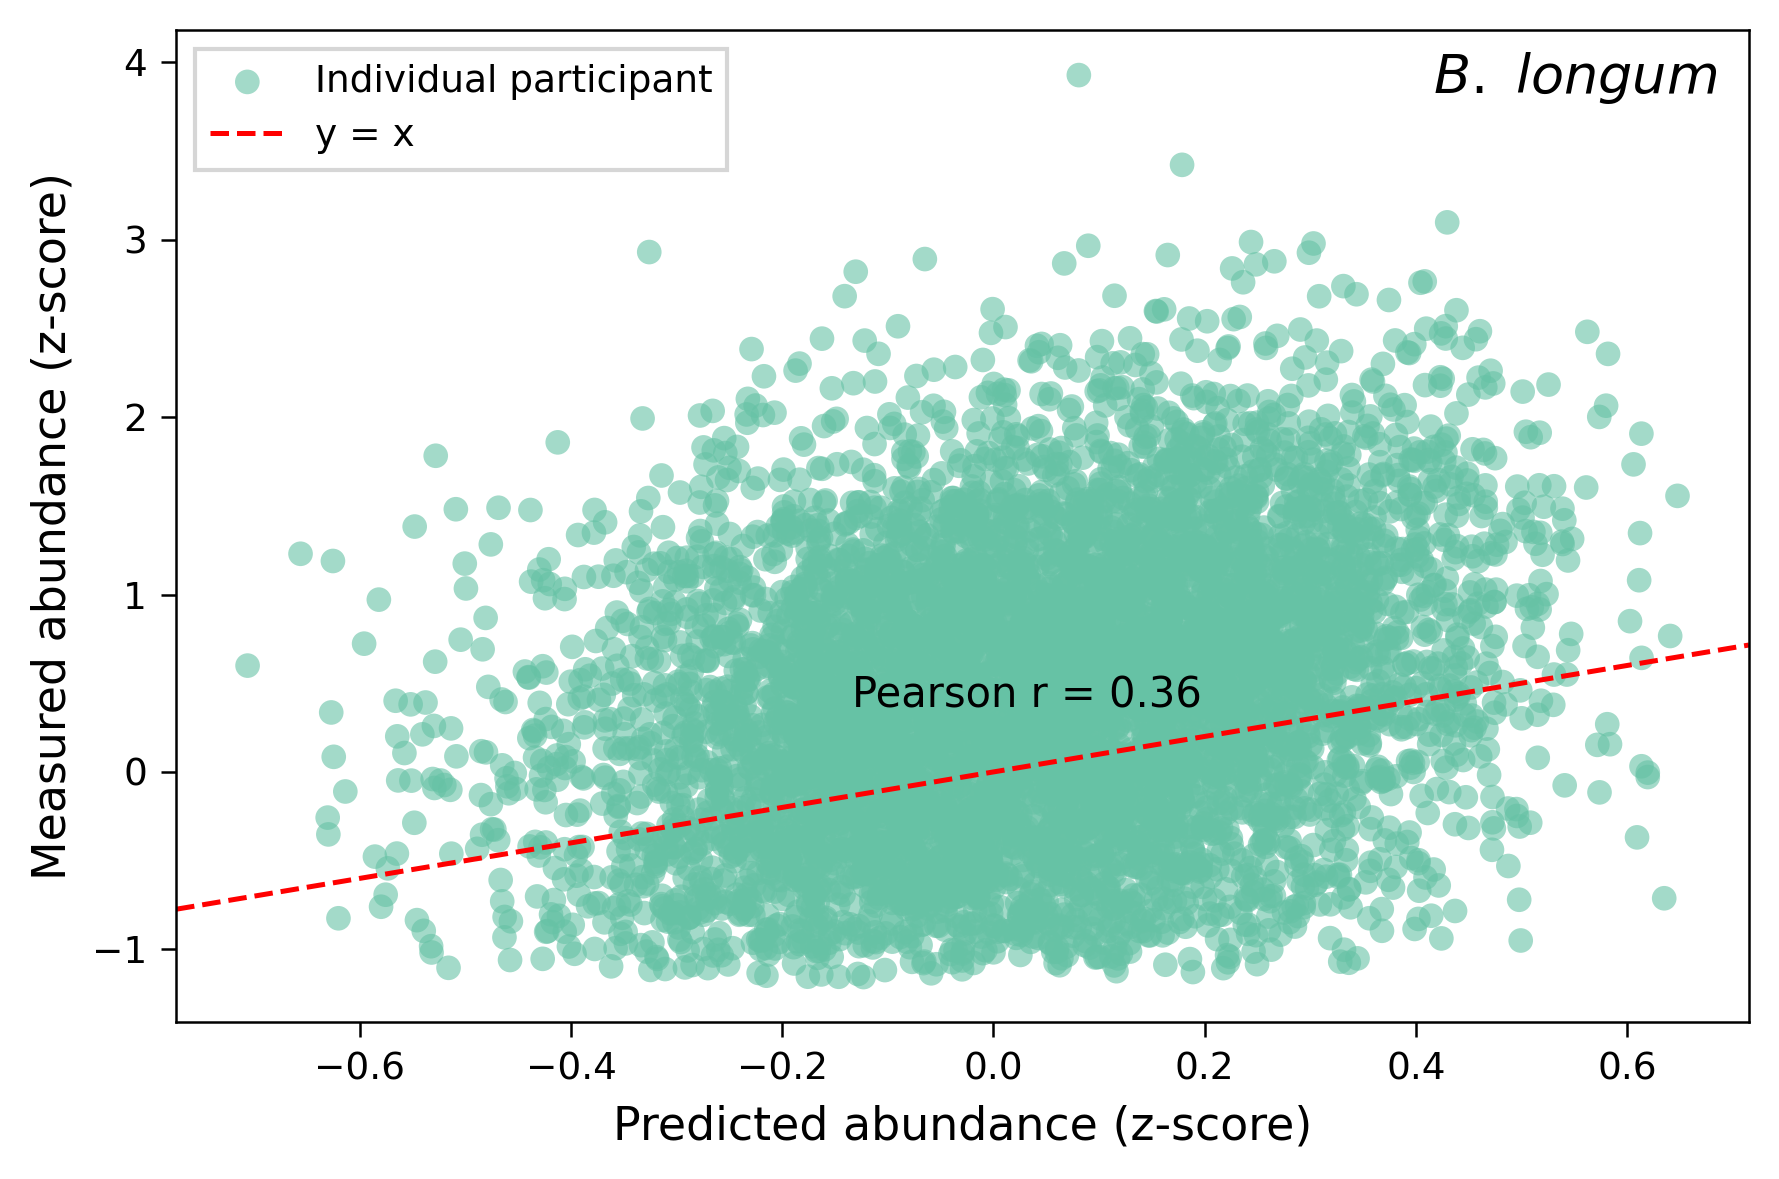

In [75]:
# ====================================================================
# Predicted vs True scatter — Nature panel-safe version
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats

# ======================
# SETTINGS
# ======================
SPECIES = "segal_species"
home_path = "/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/"
MICROBE_I = 34

AXIS_MODE = "minmax"      # "minmax" or "percentile"
PCTL_LIM = (0.05, 99.95)
PAD_FRAC = 0.05

DECIMALS_FOR_FLOOR = 3
MIN_FLOOR_FRACTION = 0.01

DPI = 300

# --- NEW: label style toggle ---
# "corner" -> inside-axes corner label
# "title"  -> title above plot
# None     -> no species label
LABEL_MODE = "corner"     # <-- change to "title" if you prefer
# ======================


# --------------------------------------------------------------------
# 0. Reset + Nature style (IDENTICAL to other panels)
# --------------------------------------------------------------------
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("nature_single.mplstyle")

FONT = 9
mpl.rcParams.update({
    "font.size": FONT,
    "axes.labelsize": FONT + 2,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT,
})


# --------------------------------------------------------------------
# 1. Colors — SAME Set2 source
# --------------------------------------------------------------------
set2 = cm.get_cmap("Set2").colors
DOT_COLOR = set2[0]


# --------------------------------------------------------------------
# 2. Helper functions
# --------------------------------------------------------------------
def read_results(df):
    return tuple(df[col] for col in df.columns)


def detect_constant_floor_from_targets(y_true, decimals=3, min_frac=0.01):
    y = np.asarray(y_true, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    y_round = np.round(y, decimals)
    vals, cnts = np.unique(y_round, return_counts=True)
    j = int(np.argmax(cnts))
    floor_val = float(vals[j])
    floor_frac = float(cnts[j]) / float(cnts.sum())
    return floor_val if floor_frac >= min_frac else None


def compute_limits(a, mode="minmax", pctl=(0.05, 99.95), pad_frac=0.05):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return (-1, 1)

    if mode == "percentile":
        lo, hi = np.percentile(a, list(pctl))
    else:
        lo, hi = float(np.min(a)), float(np.max(a))

    if lo == hi:
        lo -= 1.0
        hi += 1.0

    span = hi - lo
    return (lo - pad_frac * span, hi + pad_frac * span)


def get_microbe_display_name(species_key: str, microbe_i: int, home_path_: str):
    """
    Returns:
      full_name: e.g. "Bifidobacterium longum"
      short_name: e.g. "B. longum"
      no_space_short: e.g. "B.longum"
    """
    try:
        mb_names = pd.read_pickle(home_path_ + "data/mb_names.pkl")
        full_name = mb_names.loc[microbe_i, "species_new"]
    except Exception:
        full_name = f"Microbe {microbe_i}"

    parts = str(full_name).split()
    if len(parts) >= 2:
        short_name = f"{parts[0][0]}. {parts[1]}"
        no_space_short = f"{parts[0][0]}.{parts[1]}"
    else:
        short_name = str(full_name)
        no_space_short = str(full_name)

    return str(full_name), short_name, no_space_short


# --------------------------------------------------------------------
# 3. Load results
# --------------------------------------------------------------------
obj = pd.read_pickle(home_path + f"data/regression/{SPECIES}/output_LGBM_abundance.pkl")
lgbm_diet_scores, lgbm_diet_pvalues, lgbm_diet_coefs, lgbm_diet_preds, lgbm_diet_targets = read_results(obj)

y_pred = np.asarray(lgbm_diet_preds.iloc[MICROBE_I], dtype=float)
y_true = np.asarray(lgbm_diet_targets.iloc[MICROBE_I], dtype=float)

ok = np.isfinite(y_pred) & np.isfinite(y_true)
x_all = y_pred[ok]
y_all = y_true[ok]

# Pearson r (full)
r_all, _ = stats.pearsonr(x_all, y_all) if x_all.size >= 3 else (np.nan, np.nan)

# Remove absent floor
floor_val = detect_constant_floor_from_targets(y_all, DECIMALS_FOR_FLOOR, MIN_FLOOR_FRACTION)
if floor_val is not None:
    tol = 0.5 * (10 ** (-DECIMALS_FOR_FLOOR))
    present_mask = np.abs(y_all - floor_val) > tol
else:
    present_mask = np.ones_like(y_all, dtype=bool)

x = x_all[present_mask]
y = y_all[present_mask]

full_name, short_name, no_space_short = get_microbe_display_name(SPECIES, MICROBE_I, home_path)


# --------------------------------------------------------------------
# 4. Figure — CANONICAL panel size
# --------------------------------------------------------------------
FIG_W = 6.0
FIG_H = 4.0  # panel-safe

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)

ax.scatter(
    x, y,
    s=35,
    alpha=0.6,
    color=DOT_COLOR,
    edgecolor="none",
    label="Individual participant",
)

# Axis limits
xlim = compute_limits(x, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ylim = compute_limits(y, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# y = x reference
line_min = max(xlim[0], ylim[0])
line_max = min(xlim[1], ylim[1])
ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="red",
    linewidth=1.2,
    label="y = x",
)

# Pearson r annotation
ax.text(
    0.43, 0.35,
    f"Pearson r = {r_all:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=FONT + 1,
)

# --- NEW: label mode (corner OR title) ---
if LABEL_MODE == "corner":
    ax.text(
        0.98, 0.98,
        r"$\it{B.}$ $\it{longum}$",   # ✅ both italic
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=FONT + 4,
    )
elif LABEL_MODE == "title":
    ax.set_title(r"$\it{Bifidobacterium\ longum}$", pad=6)

ax.set_xlabel("Predicted abundance (z-score)")
ax.set_ylabel("Measured abundance (z-score)")

ax.legend(frameon=True, fancybox=False, loc="upper left")
fig.tight_layout()


fig.savefig(
    home_path + f"figures/regression/{SPECIES}/Bifidobacterium_longum_true_predicted.png",
    dpi=300,
    facecolor="white",
    transparent=False,
    bbox_inches="tight"
)
fig.savefig(
    home_path + f"figures/regression/{SPECIES}/Bifidobacterium_longum_true_predicted.pdf",
    dpi=300,
    facecolor="white",
    transparent=False,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


### Bacteria will low r

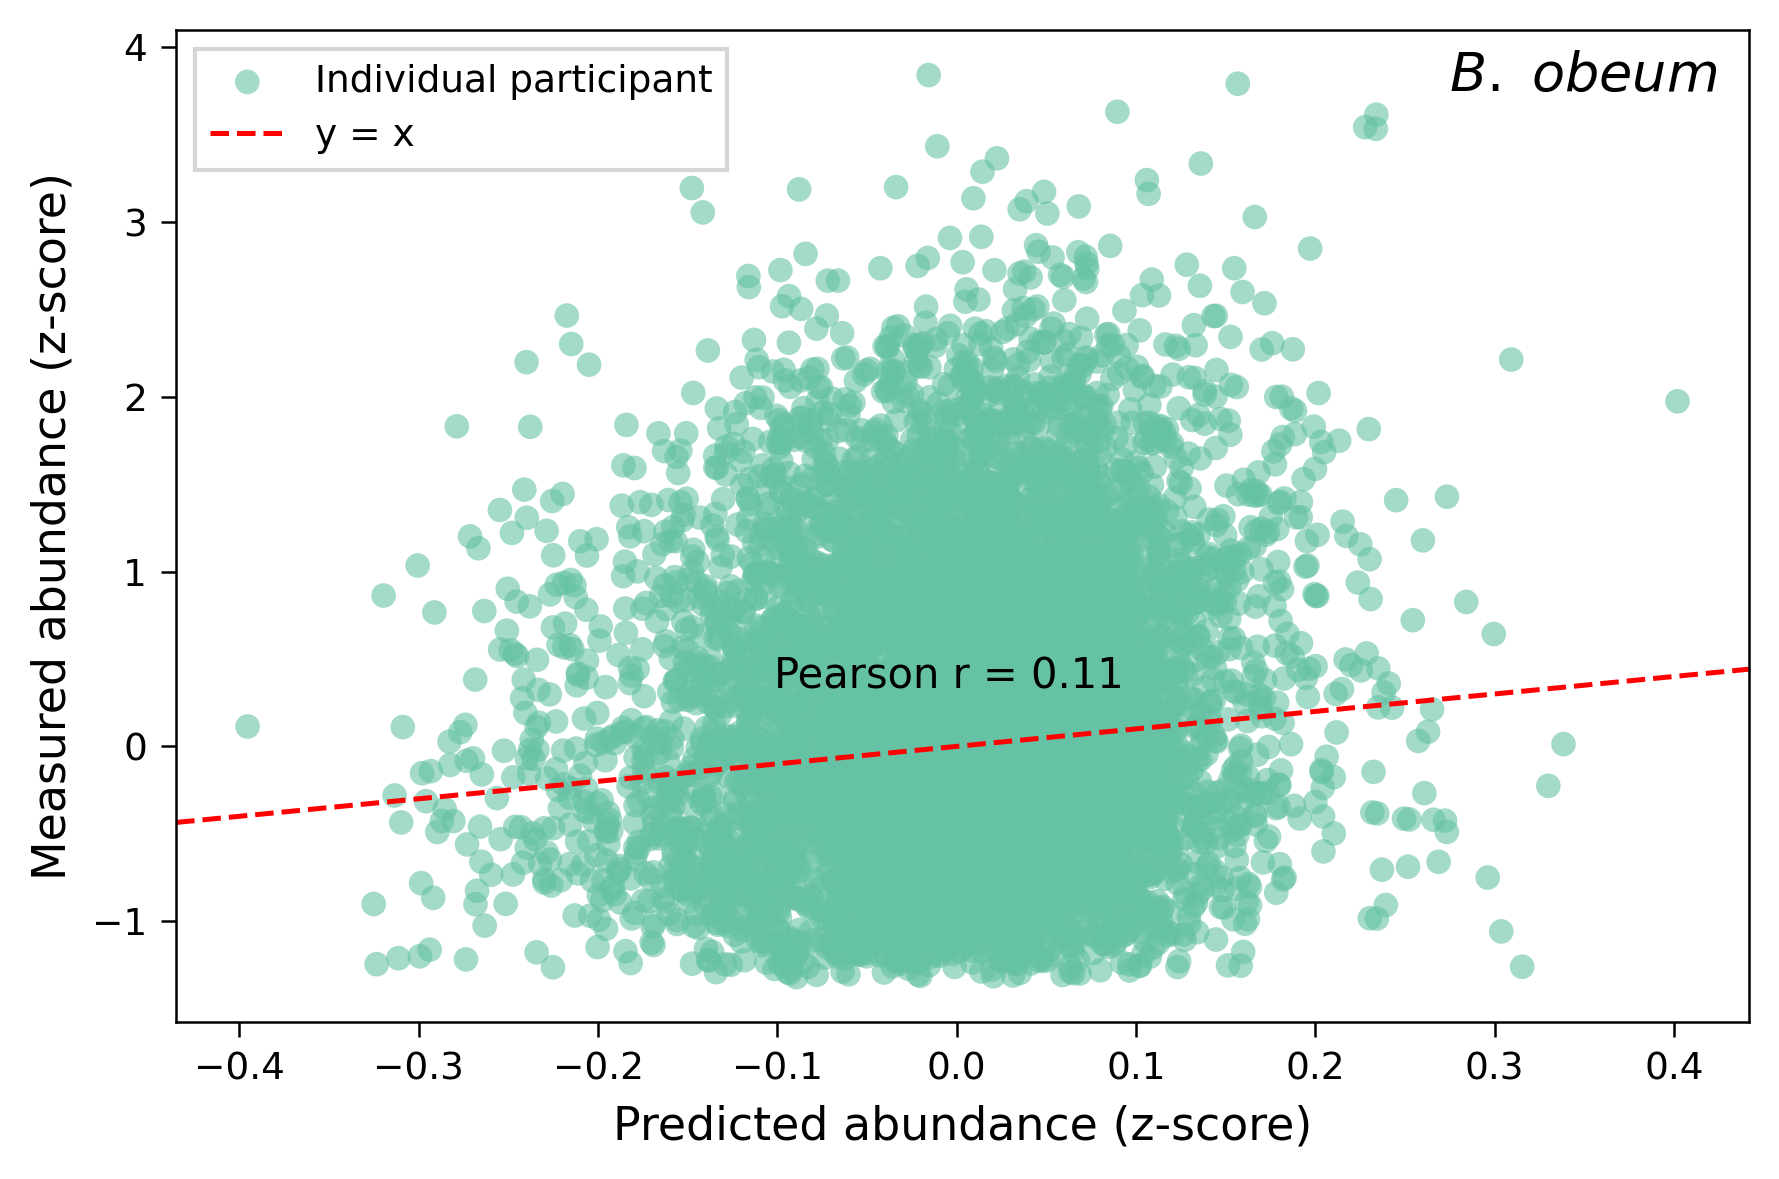

Saved to: /net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/figures/pred_vs_true_examples/segal_species/pred_vs_true_M.310_i310_r0.11.png


In [74]:
# ====================================================================
# Predicted vs True scatter — Nature panel-safe version
# ====================================================================

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats

# ======================
# SETTINGS
# ======================
SPECIES = "segal_species"
home_path = "/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/"
MICROBE_I = 310  # <-- your chosen low-corr example (Blautia obeum)

AXIS_MODE = "minmax"      # "minmax" or "percentile"
PCTL_LIM = (0.05, 99.95)
PAD_FRAC = 0.05

DECIMALS_FOR_FLOOR = 3
MIN_FLOOR_FRACTION = 0.01

DPI = 300

# --- label style toggle ---
LABEL_MODE = "corner"     # "corner" | "title" | None

# --- NEW: save to a different path ---
OUT_DIR = home_path + f"figures/pred_vs_true_examples/{SPECIES}/"
# ======================


# --------------------------------------------------------------------
# 0. Reset + Nature style (IDENTICAL to other panels)
# --------------------------------------------------------------------
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("nature_single.mplstyle")

FONT = 9
mpl.rcParams.update({
    "font.size": FONT,
    "axes.labelsize": FONT + 2,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT,
})


# --------------------------------------------------------------------
# 1. Colors — SAME Set2 source
# --------------------------------------------------------------------
set2 = cm.get_cmap("Set2").colors
DOT_COLOR = set2[0]


# --------------------------------------------------------------------
# 2. Helper functions
# --------------------------------------------------------------------
def read_results(df):
    return tuple(df[col] for col in df.columns)


def detect_constant_floor_from_targets(y_true, decimals=3, min_frac=0.01):
    y = np.asarray(y_true, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    y_round = np.round(y, decimals)
    vals, cnts = np.unique(y_round, return_counts=True)
    j = int(np.argmax(cnts))
    floor_val = float(vals[j])
    floor_frac = float(cnts[j]) / float(cnts.sum())
    return floor_val if floor_frac >= min_frac else None


def compute_limits(a, mode="minmax", pctl=(0.05, 99.95), pad_frac=0.05):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return (-1, 1)

    if mode == "percentile":
        lo, hi = np.percentile(a, list(pctl))
    else:
        lo, hi = float(np.min(a)), float(np.max(a))

    if lo == hi:
        lo -= 1.0
        hi += 1.0

    span = hi - lo
    return (lo - pad_frac * span, hi + pad_frac * span)


def get_microbe_display_name(species_key: str, microbe_i: int, home_path_: str):
    """
    Returns:
      full_name: e.g. "Bifidobacterium longum"
      short_name: e.g. "B. longum"
      no_space_short: e.g. "B.longum"
    """
    try:
        mb_names = pd.read_pickle(home_path_ + "data/mb_names.pkl")
        full_name = mb_names.loc[microbe_i, "species_new"]
    except Exception:
        full_name = f"Microbe {microbe_i}"

    parts = str(full_name).split()
    if len(parts) >= 2:
        short_name = f"{parts[0][0]}. {parts[1]}"
        no_space_short = f"{parts[0][0]}.{parts[1]}"
    else:
        short_name = str(full_name)
        no_space_short = str(full_name)

    return str(full_name), short_name, no_space_short


# --------------------------------------------------------------------
# 3. Load results
# --------------------------------------------------------------------
obj = pd.read_pickle(home_path + f"data/regression/{SPECIES}/output_LGBM_abundance.pkl")
lgbm_diet_scores, lgbm_diet_pvalues, lgbm_diet_coefs, lgbm_diet_preds, lgbm_diet_targets = read_results(obj)

y_pred = np.asarray(lgbm_diet_preds.iloc[MICROBE_I], dtype=float)
y_true = np.asarray(lgbm_diet_targets.iloc[MICROBE_I], dtype=float)

ok = np.isfinite(y_pred) & np.isfinite(y_true)
x_all = y_pred[ok]
y_all = y_true[ok]

# Pearson r (full)
r_all, _ = stats.pearsonr(x_all, y_all) if x_all.size >= 3 else (np.nan, np.nan)

# Remove absent floor
floor_val = detect_constant_floor_from_targets(y_all, DECIMALS_FOR_FLOOR, MIN_FLOOR_FRACTION)
if floor_val is not None:
    tol = 0.5 * (10 ** (-DECIMALS_FOR_FLOOR))
    present_mask = np.abs(y_all - floor_val) > tol
else:
    present_mask = np.ones_like(y_all, dtype=bool)

x = x_all[present_mask]
y = y_all[present_mask]

full_name, short_name, no_space_short = get_microbe_display_name(SPECIES, MICROBE_I, home_path)


# --------------------------------------------------------------------
# 4. Figure — CANONICAL panel size
# --------------------------------------------------------------------
FIG_W = 6.0
FIG_H = 4.0  # panel-safe

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)

ax.scatter(
    x, y,
    s=35,
    alpha=0.6,
    color=DOT_COLOR,
    edgecolor="none",
    label="Individual participant",
)

# Axis limits
xlim = compute_limits(x, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ylim = compute_limits(y, AXIS_MODE, PCTL_LIM, PAD_FRAC)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# y = x reference
line_min = max(xlim[0], ylim[0])
line_max = min(xlim[1], ylim[1])
ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="red",
    linewidth=1.2,
    label="y = x",
)

# Pearson r annotation
ax.text(
    0.38, 0.37,
    f"Pearson r = {r_all:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=FONT + 1,
)

# --- UPDATED: label mode (corner OR title) for Blautia obeum ---
if LABEL_MODE == "corner":
    ax.text(
        0.98, 0.98,
        r"$\it{B.}$ $\it{obeum}$",   # ✅ both italic
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=FONT + 4,
    )
elif LABEL_MODE == "title":
    ax.set_title(r"$\it{Blautia\ obeum}$", pad=6)

ax.set_xlabel("Predicted abundance (z-score)")
ax.set_ylabel("Measured abundance (z-score)")

ax.legend(frameon=True, fancybox=False, loc="upper left")
fig.tight_layout()

# --------------------------------------------------------------------
# 5. Save (different path)
# --------------------------------------------------------------------

fig.savefig(
    home_path + f"figures/regression/{SPECIES}/Blautia_obeum_true_predicted.png",
    dpi=300,
    facecolor="white",
    transparent=False,
    bbox_inches="tight"
)
fig.savefig(
    home_path + f"figures/regression/{SPECIES}/Blautia_obeum_true_predicted.pdf",
    dpi=300,
    facecolor="white",
    transparent=False,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


In [64]:
import re
import pickle
import pandas as pd
from collections import defaultdict

# --- load target_input (raw IDs) ---
with open(home_path + f"data/{SPECIES}/my_lists.pkl", "rb") as f:
    base_features, features, target_input = pickle.load(f)

# --- load mb_names (adjust to your actual path / file type) ---
# mb_names must have index = raw IDs, and columns: species_new, genus_new, family_new
mb_names = pd.read_pickle(home_path + "data/mb_names.pkl")   # <-- CHANGE if needed

# --- build mapping for target_input, matching your function ---
mb_names = mb_names.copy()
mb_names.index = mb_names.index.astype(str).str.strip()

species_map = mb_names["species_new"].astype(str).str.strip()
genus_map   = mb_names["genus_new"].astype(str).str.strip()
family_map  = mb_names["family_new"].astype(str).str.strip()

preliminary = {}
for raw in target_input:
    raw = str(raw).strip()
    name = species_map.get(raw, None)
    if name == "unknown" or pd.isna(name):
        name = genus_map.get(raw, None)
    if name == "unknown" or pd.isna(name):
        name = family_map.get(raw, None)
    if name is None or name == "unknown" or pd.isna(name):
        name = raw
    preliminary[raw] = name

# dedup suffixes in a deterministic order (target_input order)
counter = defaultdict(int)
final = {}
for raw in target_input:
    base = preliminary[str(raw).strip()]
    counter[base] += 1
    final_name = base if counter[base] == 1 else f"{base}_{counter[base]-1}"
    final[str(raw).strip()] = final_name

def sanitize(x):
    return re.sub(r"[^a-zA-Z0-9_]", "_", str(x))

pretty_names = [sanitize(final[str(raw).strip()]) for raw in target_input]

obj = pd.read_pickle(home_path + f"data/regression/{SPECIES}/output_LGBM_abundance.pkl")
lgbm_diet_scores, lgbm_diet_pvalues, *_ = read_results(obj)

results = pd.DataFrame({
    "bacterium": [pretty_names[i] for i in lgbm_diet_scores.index],
    "corr": lgbm_diet_scores.values,
    "pval": lgbm_diet_pvalues.values,
}).sort_values("corr", ascending=True)

results = results[results['corr'] > 0.1]

In [65]:
results.head(50)

,bacterium,corr,pval
181,Fimisoma_avicola,0.100241,1.476617e-19
311,Blautia_A_sp900066355,0.100676,1.028900e-19
639,Eubacterium_R_sp000434995,0.100755,9.628548e-20
437,Adlercreutzia_rubneri,0.100760,9.590492e-20
54,Holdemania_massiliensis,0.100798,9.288804e-20
707,Alistipes_communis,0.100892,8.589881e-20
371,Neoclostridium_roslinense,0.101489,5.205329e-20
128,HGM10766_sp900757295,0.101991,3.410707e-20
158,Phascolarctobacterium_A_sp900753045,0.102351,2.515623e-20
597,HGM13222_sp900757485,0.102469,2.274754e-20


In [36]:
lgbm_diet_scores.mean()

0.10913937173690377

In [37]:
lgbm_diet_targets

0      [-0.2549606927418267, -0.2549606927418267, -0....
1      [3.1203914552768683, -0.2555888481959606, -0.2...
2      [-0.487389584444001, -0.487389584444001, -0.48...
3      [-1.0070003928634281, 0.5273768772856408, -1.0...
4      [3.4065133748747756, -0.3183621001064964, -0.3...
                             ...                        
719    [-0.24556211750322146, -0.24556211750322146, -...
720    [-0.237235110431065, -0.237235110431065, -0.23...
721    [-0.2739507900525653, -0.2739507900525653, -0....
722    [-0.7916856776986902, -0.49467953398767095, 2....
723    [-0.4126156877592507, -0.4126156877592507, 1.5...
Name: 4, Length: 724, dtype: object

<Figure size 1800x1800 with 0 Axes>

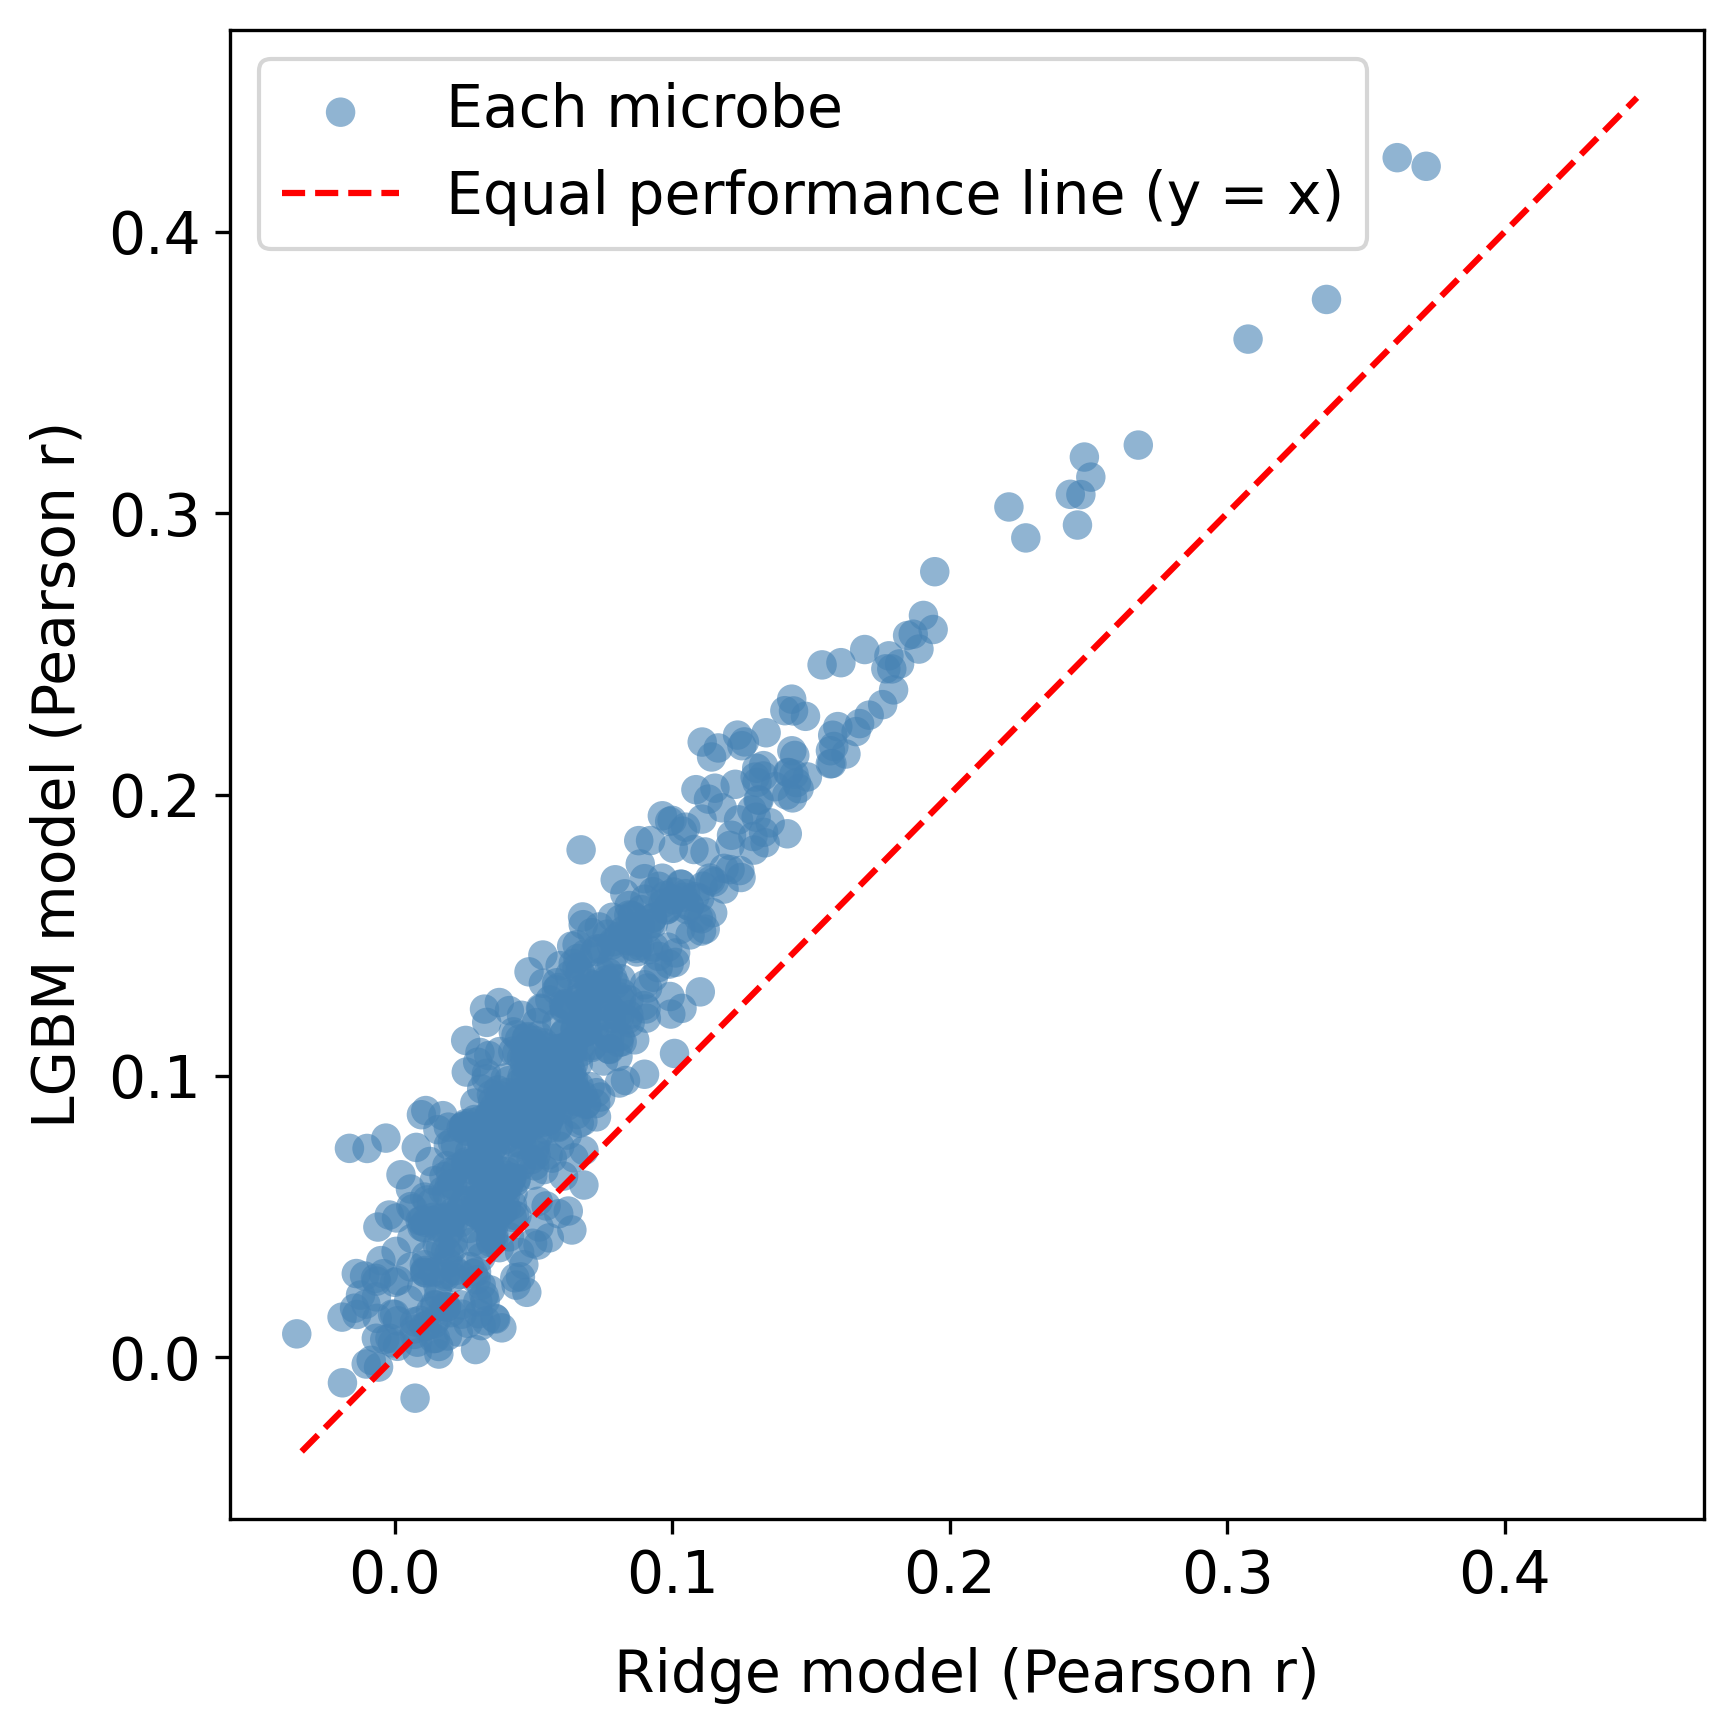

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Reset to clean defaults
plt.figure(figsize=(6, 6), dpi=300)

# === Assemble and clean ===
to_plot = pd.concat([ridge_diet_scores, lgbm_diet_scores], axis=1).dropna()
to_plot.columns = ["Ridge correlations", "LGBM correlations"]

# Pearson correlation
r_val, p_val = stats.pearsonr(
    to_plot["Ridge correlations"],
    to_plot["LGBM correlations"]
)

# === Create figure ===
plt.figure(figsize=(6, 6), dpi=300)

# Scatter (same style as previous figure)
plt.scatter(
    to_plot["Ridge correlations"],
    to_plot["LGBM correlations"],
    color='steelblue',
    alpha=0.6,
    edgecolor='none',
    s=50,
    label="Each microbe"
)

# y = x reference line (renamed legend label)
lims = [min(to_plot.min()) * 0.95, max(to_plot.max()) * 1.05]
plt.plot(
    lims,
    lims,
    'r--',
    linewidth=1.5,
    label='Equal performance line (y = x)'
)

# --- Place annotation close to the red line ---
x_line = np.median(to_plot["Ridge correlations"])
y_line = x_line

# === Labels and title ===
plt.xlabel("Ridge model (Pearson r)", labelpad=10)
plt.ylabel("LGBM model (Pearson r)", labelpad=5)
# plt.title("Comparison of Ridge vs LGBM correlations")

# === Legend and layout ===
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
plt.clf()
